# BME-336546-C06-Nonlinear classification (SVM and Random forest) - Solution


## Data loading

In [1]:

import numpy as np
import pickle
import sys
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.style.use(['ggplot']) 
%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline

In this tutorial we would use data that you can find within `sklearn.datasets`. The chosen data are concentric circles.

In [2]:
from sklearn.datasets import make_circles
X, y = make_circles(1000, factor=.1, noise=.2, random_state=336546)

As usual, we should split our data into training and testing sets:

In [3]:
X_train, x_test, Y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 10, stratify=y)

In [4]:
def plot_radar(clf, clf_type):
    labels=np.array(['Accuracy', 'F1', 'PPV', 'Sensitivity', 'AUROC']) 
    score_mat_train = np.stack((clf.cv_results_['mean_train_accuracy'], clf.cv_results_['mean_train_f1'],
                               clf.cv_results_['mean_train_precision'], clf.cv_results_['mean_train_recall'],
                               clf.cv_results_['mean_train_roc_auc']), axis=0)
    score_mat_val = np.stack((clf.cv_results_['mean_test_accuracy'], clf.cv_results_['mean_test_f1'],
                               clf.cv_results_['mean_test_precision'], clf.cv_results_['mean_test_recall'],
                               clf.cv_results_['mean_test_roc_auc']), axis=0)


    angles=np.linspace(0, 2*np.pi, len(labels), endpoint=False)

    angles=np.concatenate((angles,[angles[0]]))
    cv_dict = clf.cv_results_['params']
    fig=plt.figure(figsize=(18,14))
    if 'svm__gamma' in cv_dict[0]:
        new_list = [(i, item) for i, item in enumerate(cv_dict) if
                    item["svm__kernel"] == clf_type[0] and item["svm__gamma"] == clf_type[1]]
    else:
        new_list = [(i, item) for i, item in enumerate(cv_dict) if
                    item["svm__kernel"] == clf_type[0]]
    for idx, val in enumerate(new_list):
        ax = fig.add_subplot(1, len(new_list), 1+idx, polar=True)
        rel_idx, rel_dict = val
        stats_train = score_mat_train[:, rel_idx]
        stats_train=np.concatenate((stats_train,[stats_train[0]]))
        ax.plot(angles, stats_train, 'o-', linewidth=2)
        ax.fill(angles, stats_train, alpha=0.25)
        stats_val = score_mat_val[:, rel_idx]
        stats_val=np.concatenate((stats_val,[stats_val[0]]))
        ax.plot(angles, stats_val, 'o-', linewidth=2)
        ax.fill(angles, stats_val, alpha=0.25)
        ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
        if idx == 0:
            ax.set_ylabel(clf_type[0], fontsize=18)
        ax.set_title('C = %.3f' % (rel_dict['svm__C']))
        if 'svm__gamma' in cv_dict[0]:
            ax.set_xlabel('$\\gamma = %s $' % (rel_dict['svm__gamma']))
        ax.set_ylim([0,1])
        ax.legend(['Train','Validation'])
        ax.grid(True)
        
    plt.show()

In [5]:
def plot_dataset(x_train, x_test, y_train, y_test, axes_range):
    fig, axs = plt.subplots(1, 2, figsize=(12,6))
    for idx, ax in enumerate(axs.flatten()):
        if idx == 0:
            ax.plot(x_train[:, 0][y_train==0], x_train[:, 1][y_train==0], "bs")
            ax.plot(x_train[:, 0][y_train==1], x_train[:, 1][y_train==1], "g^")
            ax.set_title('Train')
        else:
            ax.plot(x_test[:, 0][y_test==0], x_test[:, 1][y_test==0], "bs")
            ax.plot(x_test[:, 0][y_test==1], x_test[:, 1][y_test==1], "g^")
            ax.set_title('Test')
        ax.axis(axes_range)
        ax.grid(True, which='both')
        ax.set_xlabel(r"$x_1$", fontsize=20)
        ax.set_ylabel(r"$x_2$", fontsize=20, rotation=0)
    return fig, axs

In [6]:
def plot_predictions(clf, axs, axes_range):
    x0s = np.linspace(axes_range[0], axes_range[1], 100)
    x1s = np.linspace(axes_range[2], axes_range[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    for idx, ax in enumerate(axs.flatten()):
        ax.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
        ax.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)
        if idx == 0:
            ax.set_title('Train')
        else:
            ax.set_title('Test')

Let's look at our data sets:

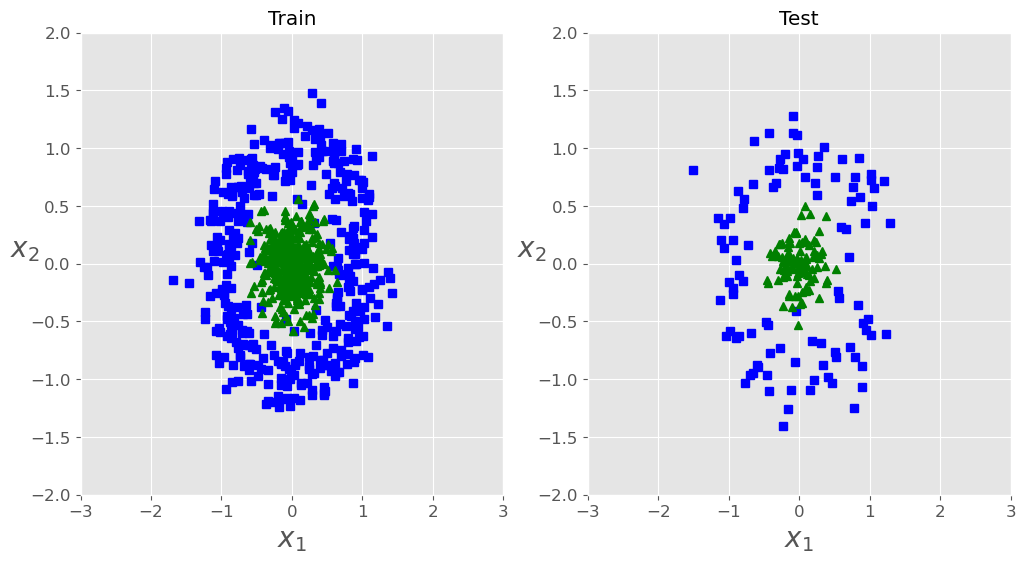

In [7]:
axes_range = [-3, 3, -2, 2]
_, _ = plot_dataset(X_train, x_test, Y_train, y_test, axes_range)

This data set is clearly non-linearly separable, at least not at this domain. We should now use the `StratifiedKFold` class as in the previous tutorial with 3 splits and then we will use `GridSearchCV` to look for the best linear SVM among the different given C values for classification penalties. Use `Pipeline` to insert scaling and notice that the kernel should not be a string but rather a one-element list containing the adequate string for linear kernel.\
Again, we would look for the best estimator according to AUROC performance and for "running info" we would use `verbose=3`. Name the `GridSearchCV` as `svm_lin` and use `svm` string for the dictionary of `Pipeline`.

In [8]:
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, random_state=10, shuffle=True)

In [9]:
#C1
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC(probability=True, random_state=336546)
C = np.array([0.001, 0.01, 1, 10, 100, 1000])
#--------------------------Implement your code here:-------------------------------------
pipe = Pipeline(steps=[('scale', StandardScaler()), ('svm', svc)])
param_grid = {'svm__kernel': ['linear'], 'svm__C': C}
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc'}
svm_lin = GridSearchCV(pipe, param_grid, cv=skf, scoring=scoring, refit='roc_auc', verbose=3, return_train_score=True)
svm_lin.fit(X_train, Y_train)
#------------------------------------------------------------------------------------------

Fitting 3 folds for each of 6 candidates, totalling 18 fits


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 1/3] END svm__C=0.001, svm__kernel=linear; accuracy: (train=0.501, test=0.498) f1: (train=0.000, test=0.000) precision: (train=0.000, test=0.000) recall: (train=0.000, test=0.000) roc_auc: (train=0.525, test=0.439) total time=   0.2s
[CV 2/3] END svm__C=0.001, svm__kernel=linear; accuracy: (train=0.501, test=0.498) f1: (train=0.667, test=0.665) precision: (train=0.501, test=0.498) recall: (train=1.000, test=1.000) roc_auc: (train=0.515, test=0.485) total time=   0.0s
[CV 3/3] END svm__C=0.001, svm__kernel=linear; accuracy: (train=0.674, test=0.677) f1: (train=0.746, test=0.750) precision: (train=0.612, test=0.611) recall: (train=0.955, test=0.970) roc_auc: (train=0.517, test=0.479) total time=   0.0s
[CV 1/3] END svm__C=0.01, svm__kernel=linear; accuracy: (train=0.501, test=0.494) f1: (train=0.000, test=0.000) precision: (train=0.000, test=0.000) recall: (train=0.000, test=0.000) roc_auc: (train=0.526, test=0.439) total time=   0.0s


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[CV 2/3] END svm__C=0.01, svm__kernel=linear; accuracy: (train=0.501, test=0.498) f1: (train=0.667, test=0.665) precision: (train=0.501, test=0.498) recall: (train=1.000, test=1.000) roc_auc: (train=0.515, test=0.485) total time=   0.0s
[CV 3/3] END svm__C=0.01, svm__kernel=linear; accuracy: (train=0.674, test=0.677) f1: (train=0.746, test=0.750) precision: (train=0.612, test=0.611) recall: (train=0.955, test=0.970) roc_auc: (train=0.517, test=0.479) total time=   0.1s
[CV 1/3] END svm__C=1.0, svm__kernel=linear; accuracy: (train=0.675, test=0.610) f1: (train=0.745, test=0.706) precision: (train=0.613, test=0.568) recall: (train=0.951, test=0.933) roc_auc: (train=0.524, test=0.440) total time=   0.1s
[CV 2/3] END svm__C=1.0, svm__kernel=linear; accuracy: (train=0.672, test=0.640) f1: (train=0.750, test=0.724) precision: (train=0.606, test=0.586) recall: (train=0.981, test=0.947) roc_auc: (train=0.514, test=0.488) total time=   0.0s
[CV 3/3] END svm__C=1.0, svm__kernel=linear; accuracy:

,estimator,Pipeline(step...ate=336546))])
,param_grid,"{'svm__C': array([1.e-03...e+02, 1.e+03]), 'svm__kernel': ['linear']}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,None
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


Choose the best linear model and name it as `best_svm_lin`. In addition, print the parameters adequate to the best classifier

In [10]:
#C2
#--------------------------Implement your code here:-------------------------------------
best_svm_lin = svm_lin.best_estimator_
print(svm_lin.best_params_)
#-----------------------------------------------------------------------------------------

{'svm__C': np.float64(1.0), 'svm__kernel': 'linear'}


Now let's look at the performances as a function of missclassification penalties:

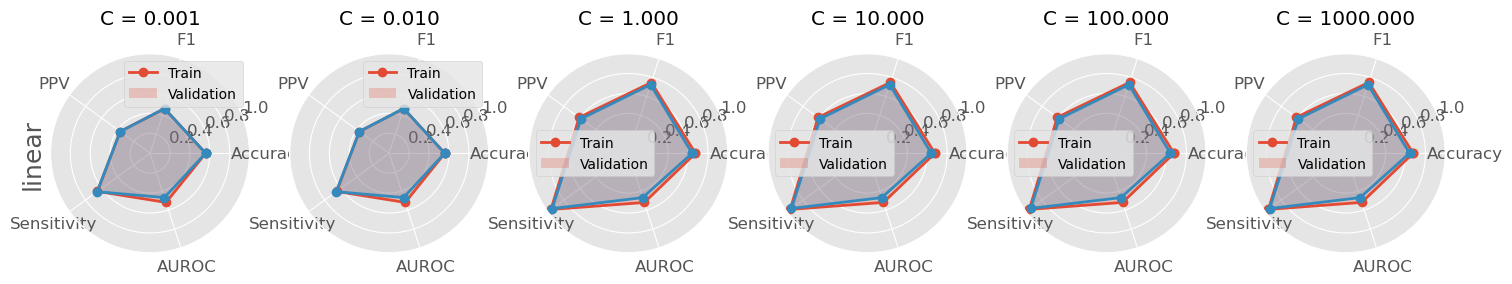

In [11]:
clf_type = ['linear']
plot_radar(svm_lin, clf_type)

And now, we would like to visualize the classification of our chosen estimator using `decision_function` method (used within `plot_predictions`).

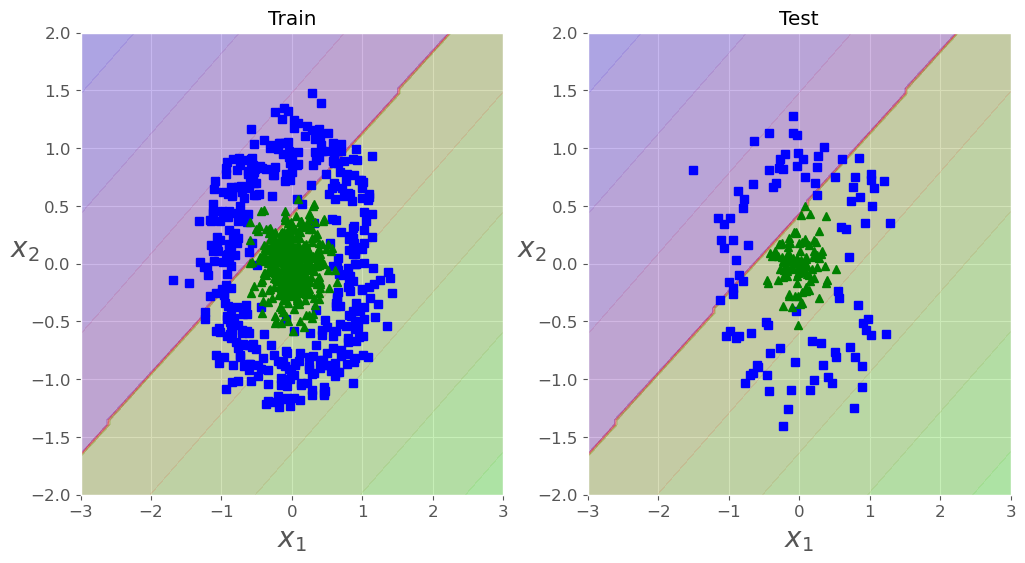

In [12]:
axes_range = [-3, 3, -2, 2]
_, axs = plot_dataset(X_train, x_test, Y_train, y_test, axes_range)
plot_predictions(best_svm_lin, axs, axes_range)

In [13]:
from sklearn.metrics import confusion_matrix
calc_TN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 0]
calc_FP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 1]
calc_FN = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 0]
calc_TP = lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[1, 1]

Calculate the statistics and plot the confusion matrix as in previous tutorial.

Sensitivity is 0.99
Specificity is 0.38
PPV is 0.61
NPV is 0.97
Accuracy is 0.69
F1 is 0.76


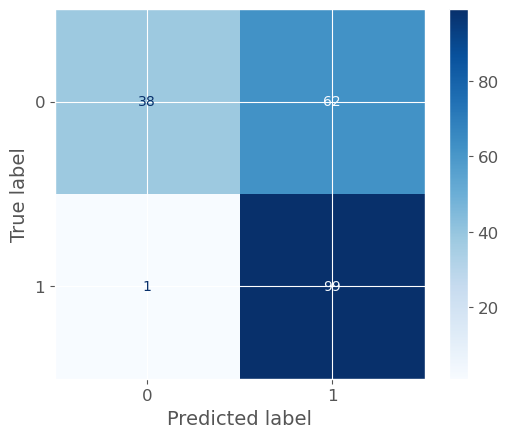

AUROC is 0.509


In [14]:
#C3
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

y_pred_test = best_svm_lin.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = best_svm_lin.predict_proba(x_test)
#--------------------------Implement your code here:-------------------------------------
TP = calc_TP(y_test, y_pred_test)
TN = calc_TN(y_test, y_pred_test)
FP = calc_FP(y_test, y_pred_test)
FN = calc_FN(y_test, y_pred_test)

Sensitivity = TP / (TP + FN)
Specificity = TN / (TN + FP)
PPV = TP / (TP + FP)
NPV = TN / (TN + FN)
Accuracy = (TP + TN) / (TP + TN + FP + FN)
F1 = 2 * PPV * Sensitivity / (PPV + Sensitivity)

print('Sensitivity is {:.2f}'.format(Sensitivity))
print('Specificity is {:.2f}'.format(Specificity))
print('PPV is {:.2f}'.format(PPV))
print('NPV is {:.2f}'.format(NPV))
print('Accuracy is {:.2f}'.format(Accuracy))
print('F1 is {:.2f}'.format(F1))

ConfusionMatrixDisplay.from_estimator(best_svm_lin, x_test, y_test, cmap='Blues', values_format='d')
plt.show()
#------------------------------------------------------------------------------------------
print('AUROC is {:.3f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

Now we would look for a **nonlinear** SVM calssifier. Use the kernels `rbf` and `poly`. For $\\gamma$, use `auto` and `scale`. The order of the polynom should be 3 (so it won't take more than several minutes). Notice to use a single-element list for this.

In [15]:
#C4
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC(probability=True)
C = np.array([1, 100, 1000])
#--------------------------Implement your code here:-------------------------------------
pipe = Pipeline(steps=[('scale', StandardScaler()), ('svm', svc)])
param_grid = {'svm__kernel': ['rbf', 'poly'], 'svm__C': C, 'svm__gamma': ['auto', 'scale'], 'svm__degree': [3]}
scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', 'roc_auc': 'roc_auc'}
svm_nonlin = GridSearchCV(pipe, param_grid, cv=skf, scoring=scoring, refit='roc_auc', verbose=3, return_train_score=True)
svm_nonlin.fit(X_train, Y_train)
#-----------------------------------------------------------------------------------------

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 1/3] END svm__C=1, svm__degree=3, svm__gamma=auto, svm__kernel=rbf; accuracy: (train=0.983, test=0.978) f1: (train=0.983, test=0.978) precision: (train=0.974, test=0.964) recall: (train=0.992, test=0.993) roc_auc: (train=0.999, test=0.997) total time=   0.1s
[CV 2/3] END svm__C=1, svm__degree=3, svm__gamma=auto, svm__kernel=rbf; accuracy: (train=0.976, test=0.978) f1: (train=0.976, test=0.977) precision: (train=0.970, test=0.985) recall: (train=0.981, test=0.970) roc_auc: (train=0.998, test=0.998) total time=   0.2s
[CV 3/3] END svm__C=1, svm__degree=3, svm__gamma=auto, svm__kernel=rbf; accuracy: (train=0.981, test=0.974) f1: (train=0.981, test=0.974) precision: (train=0.974, test=0.970) recall: (train=0.989, test=0.977) roc_auc: (train=0.999, test=0.997) total time=   0.2s
[CV 1/3] END svm__C=1, svm__degree=3, svm__gamma=auto, svm__kernel=poly; accuracy: (train=0.602, test=0.588) f1: (train=0.715, test=0.709) precision: 

,estimator,Pipeline(step...ility=True))])
,param_grid,"{'svm__C': array([ 1, 100, 1000]), 'svm__degree': [3], 'svm__gamma': ['auto', 'scale'], 'svm__kernel': ['rbf', 'poly']}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall', ...}"
,n_jobs,None
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


Choose the best estimator and name it as `best_svm_nonlin`.

---
<span style="color:red">***Question:***</span> *Which kernel do you think is more proper to use?*

---

---
<span style="color:blue">***Answer:***</span> **The RBF (Radial Basis Function) kernel is more proper to use** for this dataset. The data consists of concentric circles, which has a radial symmetry pattern. The RBF kernel naturally captures this structure because it measures similarity between points based on their Euclidean distance from a center, effectively creating circular decision boundaries. The polynomial kernel (degree=3) can also separate the classes, but the RBF kernel is a more natural fit for radially symmetric data and generally achieves better performance (as confirmed by the GridSearchCV results selecting `rbf` with `gamma='auto'` as the best estimator).

---

In [16]:
#C5
#--------------------------Implement your code here:-------------------------------------
best_svm_nonlin = svm_nonlin.best_estimator_
print(svm_nonlin.best_params_)
#------------------------------------------------------------------------------------------

{'svm__C': np.int64(1), 'svm__degree': 3, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}


Now you can plot The performances as a function of missclassification penalties for different kernels and $\\gamma$.

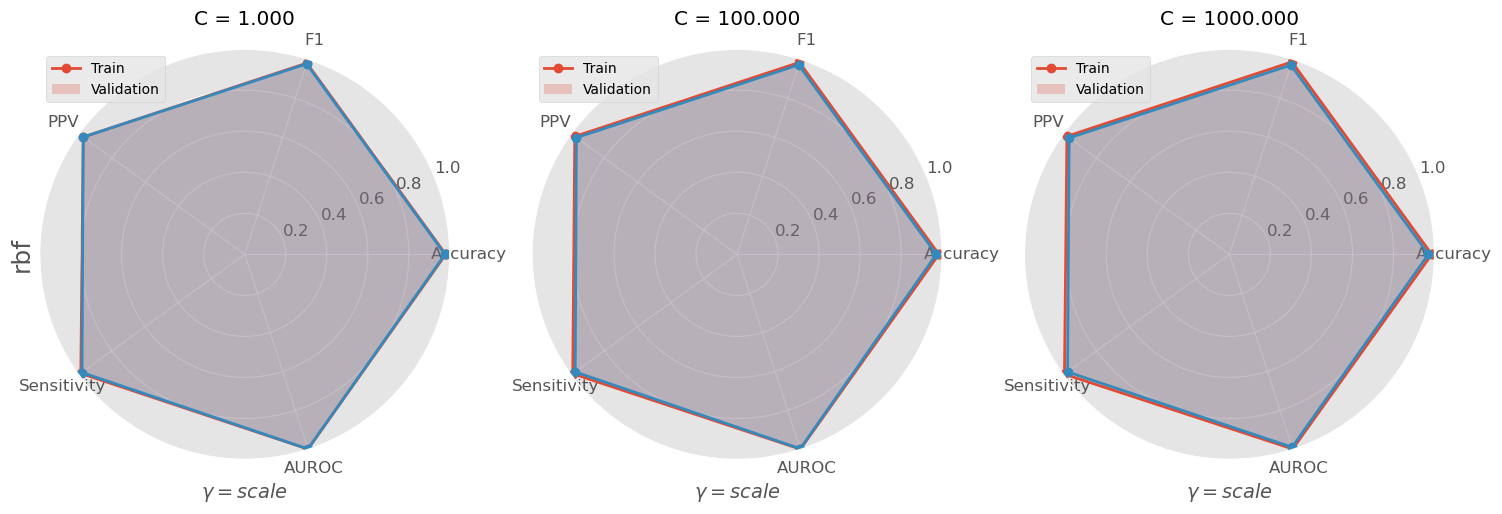

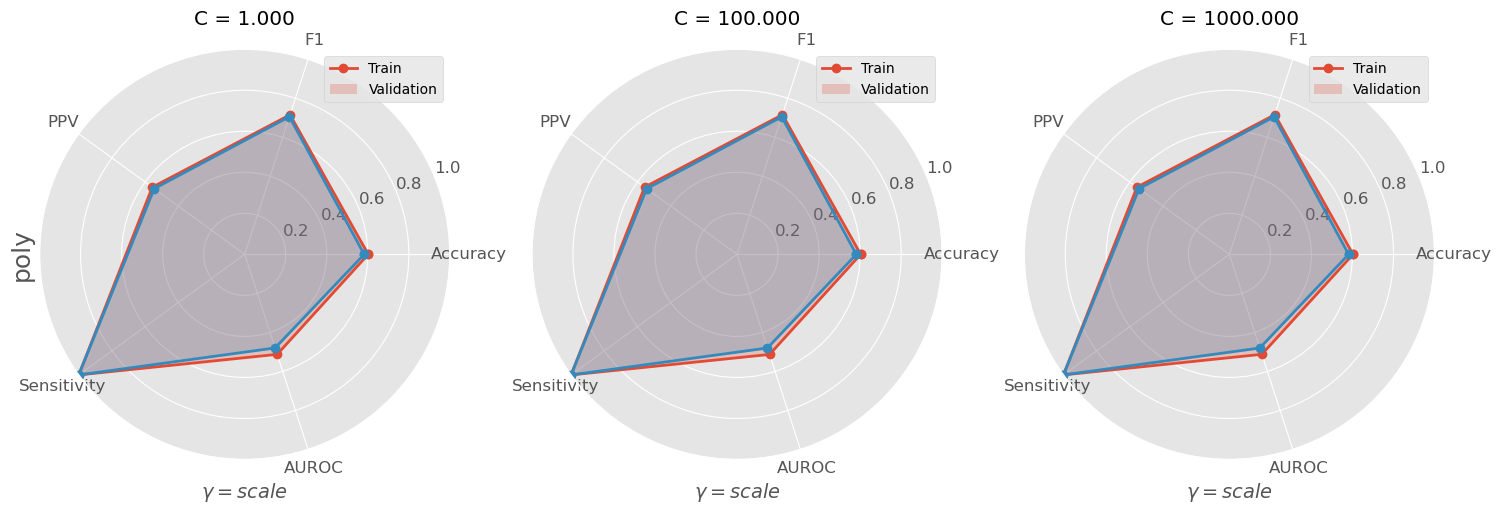

In [17]:
clf_type = ['rbf', 'scale']
plot_radar(svm_nonlin, clf_type)
clf_type = ['poly', 'scale']
plot_radar(svm_nonlin, clf_type)

Let's visualize the decision function upon our data:

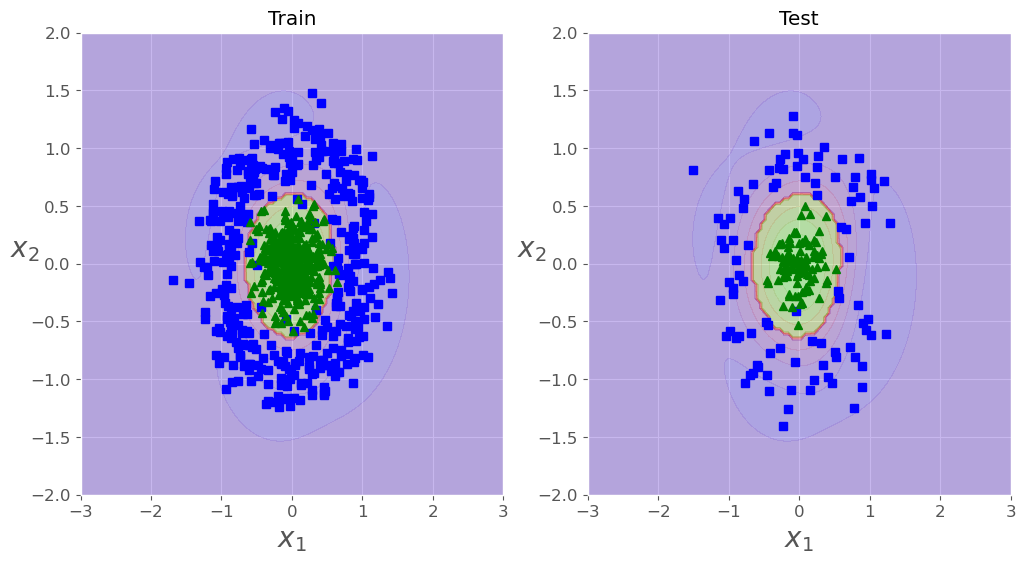

In [18]:
_, axs = plot_dataset(X_train, x_test, Y_train, y_test, axes_range)
plot_predictions(best_svm_nonlin, axs, axes_range)

Calculate the statistics and plot the confusion matrix as in previous tutorial.

Sensitivity is 1.00
Specificity is 0.99
PPV is 0.99
NPV is 1.00
Accuracy is 0.99
F1 is 1.00


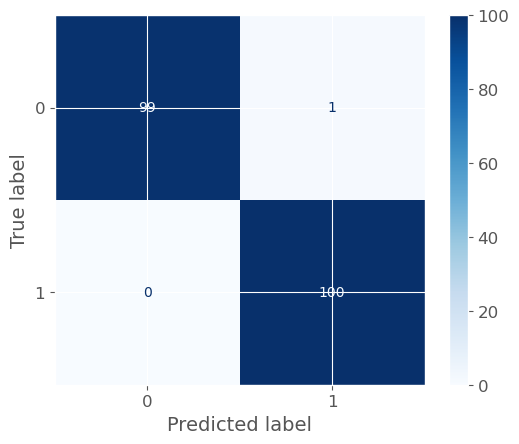

AUROC is 0.998


In [19]:
#C6
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

y_pred_test = best_svm_nonlin.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = best_svm_nonlin.predict_proba(x_test)
#--------------------------Implement your code here:-------------------------------------
TP = calc_TP(y_test, y_pred_test)
TN = calc_TN(y_test, y_pred_test)
FP = calc_FP(y_test, y_pred_test)
FN = calc_FN(y_test, y_pred_test)

Sensitivity = TP / (TP + FN)
Specificity = TN / (TN + FP)
PPV = TP / (TP + FP)
NPV = TN / (TN + FN)
Accuracy = (TP + TN) / (TP + TN + FP + FN)
F1 = 2 * PPV * Sensitivity / (PPV + Sensitivity)

print('Sensitivity is {:.2f}'.format(Sensitivity))
print('Specificity is {:.2f}'.format(Specificity))
print('PPV is {:.2f}'.format(PPV))
print('NPV is {:.2f}'.format(NPV))
print('Accuracy is {:.2f}'.format(Accuracy))
print('F1 is {:.2f}'.format(F1))

ConfusionMatrixDisplay.from_estimator(best_svm_nonlin, x_test, y_test, cmap='Blues', values_format='d')
plt.show()
#------------------------------------------------------------------------------------------
print('AUROC is {:.3f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

Here, we will only introduce a powerful classifier named *random forest* that was also used in the last part of *HW1*. Calculate the statistics and plot the confusion matrix as in previous tutorial.

Sensitivity is 1.00
Specificity is 0.98
PPV is 0.98
NPV is 1.00
Accuracy is 0.99
F1 is 0.99


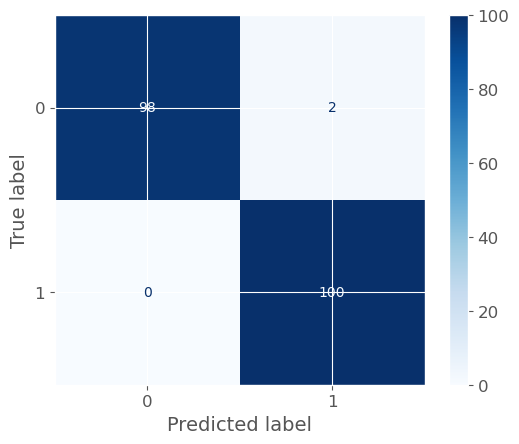

AUROC is 1.000


In [20]:
#C7
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
rfc = Pipeline(steps=[('scale', StandardScaler()), ('rfc', RandomForestClassifier(max_depth=4, random_state=336546, criterion='gini'))])
rfc.fit(X_train, Y_train)
y_pred_test = rfc.predict(x_test) #NOTICE NOT TO USE THE STANDARDIZED DATA.
y_pred_proba_test = rfc.predict_proba(x_test)
#--------------------------Implement your code here:-------------------------------------
TP = calc_TP(y_test, y_pred_test)
TN = calc_TN(y_test, y_pred_test)
FP = calc_FP(y_test, y_pred_test)
FN = calc_FN(y_test, y_pred_test)

Sensitivity = TP / (TP + FN)
Specificity = TN / (TN + FP)
PPV = TP / (TP + FP)
NPV = TN / (TN + FN)
Accuracy = (TP + TN) / (TP + TN + FP + FN)
F1 = 2 * PPV * Sensitivity / (PPV + Sensitivity)

print('Sensitivity is {:.2f}'.format(Sensitivity))
print('Specificity is {:.2f}'.format(Specificity))
print('PPV is {:.2f}'.format(PPV))
print('NPV is {:.2f}'.format(NPV))
print('Accuracy is {:.2f}'.format(Accuracy))
print('F1 is {:.2f}'.format(F1))

ConfusionMatrixDisplay.from_estimator(rfc, x_test, y_test, cmap='Blues', values_format='d')
plt.show()
#------------------------------------------------------------------------------------------
print('AUROC is {:.3f}'.format(roc_auc_score(y_test, y_pred_proba_test[:,1])))

Finally, we will compare the classifiers according to AUROC.

AttributeError: `np.round_` was removed in the NumPy 2.0 release. Use `np.round` instead.

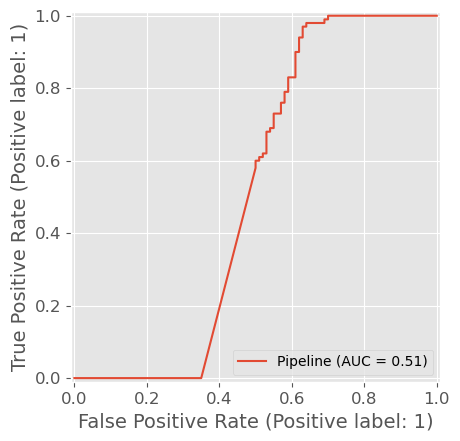

In [21]:
classifiers = [best_svm_lin, best_svm_nonlin, rfc]
roc_score = []
plt.figure()
ax = plt.gca()
for clf in classifiers:
    RocCurveDisplay.from_estimator(clf, x_test, y_test, ax=ax)
    roc_score.append(np.round_(roc_auc_score(y_test, clf.predict_proba(x_test)[:,1]), decimals=3))
ax.plot(np.linspace(0,1,x_test.shape[0]),np.linspace(0,1,x_test.shape[0]))
plt.legend(('lin_svm, AUROC = '+str(roc_score[0]),'nonlin_svm, AUROC = '+str(roc_score[1]),'rfc, AUROC = '+str(roc_score[2]),'flipping a coin'))

#### *This tutorial was written by [Moran Davoodi](mailto:morandavoodi@gmail.com) & Alon Begin with the assitance of [Yuval Ben Sason](mailto:yuvalbse@gmail.com) & Kevin Kotzen*